# The main Idea


**Purpose of work:**

 Each task indicates which type of graph should be used to visualize data. Each task requires a schedule twice: for the first time with the `seaborn` module (alternatively, `matplotlib` styles from `seaborn`), the second with the help of `plotly`, `altair` or `bokeh` to choose a student. It is not necessary to select the same library every time for the second schedule, since it is necessary to select the same library. not all libraries have the same set of charts.

# Data


At [link](https://drive.google.com/drive/folders/1e0E4vQzaE9LBZgfzz0AzsyAXgtH0eMaP?usp=share_link) there is a table with information about songs performed at Eurovision from 2009 to 2023. All laboratory tasks must be completed using these data. The full data can be found [at the link](https://www.kaggle.com/datasets/diamondsnake/eurovision-song-contest-data).

##### **Data format**

```
year,country,artist_name,song_name,language,style,gender,main_singers,key,BPM,energy,danceability,happiness,loudness,acousticness,instrumentalness,liveness,speechiness,final_place
2023,Norway,Alessandra,Queen of Kings,English,Pop,Female,1,E Minor,110,36,64,23,10 dB,58,0,10,3,5
2023,Malta,The Busker,Dance (Our Own Party),English,Pop,Male,1,F Minor,103,78,70,82,6 dB,2,0,18,4,
...
```
##### **Description of fields**

- ```year``` – year;
- ```country``` – country of the participant;
- ```artist_name``` – performer;
- ```song_name``` – song title;
- ```language``` – language the song is performed in;
- ```style``` – genre;
- ```gender``` – gender of the participant;
- ```main_singers``` – number of vocalists;
- ```key``` – register (pitch);
- ```BPM``` – overall speed of the track (quarter notes per minute);
- ```energy``` – energy level of the track;
- ```danceability``` – danceability (how suitable the track is for dancing);
- ```happiness``` – cheerfulness;
- ```loudness``` – volume; - ```acousticness``` – acoustics;
- ```instrumentalness``` – instrumentality;
- ```liveness``` – liveliness;
- ```speechiness``` – how much text there is;
- ```final_place``` – final place in the final line.

# Tasks

>A conclusion must be drawn for each task. It is also necessary to add a label for the graph and axes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import altair as alt
import seaborn as sns

In [ ]:
df = pd.read_csv('song_data.csv')
df.sample(10)

,year,country,artist_name,song_name,language,style,gender,main_singers,key,BPM,energy,danceability,happiness,loudness,acousticness,instrumentalness,liveness,speechiness,final_place
271,2016,Bulgaria,Poli Genova,If Love Was a Crime,"English, Bulgarian",Dance,Female,1,C Major,110,83,61,52,5 dB,2,0,22,3,4.0
433,2012,Bosnia and Herzegovina,Maya Sar,Korake ti znam,Bosnian,Ballad,Female,1,A Major,122,35,38,44,8 dB,71,0,24,3,18.0
47,2022,Croatia,Mia Dimsic,Guilty Pleasure,"English, Croatian",Ballad,Female,1,F Major,84,59,53,51,7 dB,12,0,14,6,NaN
365,2013,Russia,Dina Garipova,What If,English,Ballad,Female,1,-,-,-,-,-,NaN,-,-,-,-,5.0
99,2021,Moldova,Natalia Gordienko,Sugar,English,Pop,Female,1,B Minor,120,76,69,51,7 dB,0,1,13,5,13.0
92,2021,Malta,Destiny,Je me casse,English,Pop,Female,1,Ab Minor,112,87,76,78,4 dB,15,0,28,11,7.0
397,2013,Sweden,Robin Stjernberg,You,English,Dance,Male,1,-,-,-,-,-,NaN,-,-,-,-,14.0
300,2015,Lithuania,Monika Linkyte & Vaidas Baumila,This Time,English,Pop,Mix,2,Ab Major,131,87,56,32,6 dB,0,0,11,6,18.0
437,2012,Italy,Nina Zilli,L'amore e femmina (Out of Love),"English, Italian",Pop,Female,1,-,-,-,-,-,NaN,-,-,-,-,9.0
198,2018,Italy,Ermal Meta & Fabrizio Moro,Non mi avete fatto niente,Italian,Pop,Male,2,Fs Major,90,88,57,76,5 dB,34,0,16,5,5.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 565 entries, 0 to 564
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              565 non-null    int64  
 1   country           565 non-null    object 
 2   artist_name       565 non-null    object 
 3   song_name         565 non-null    object 
 4   language          565 non-null    object 
 5   style             565 non-null    object 
 6   gender            565 non-null    object 
 7   main_singers      565 non-null    int64  
 8   key               565 non-null    object 
 9   BPM               565 non-null    object 
 10  energy            565 non-null    object 
 11  danceability      565 non-null    object 
 12  happiness         565 non-null    object 
 13  loudness          475 non-null    object 
 14  acousticness      565 non-null    object 
 15  instrumentalness  565 non-null    object 
 16  liveness          565 non-null    object 
 1

## Task 1

Preprocess numerical values ​​in the dataset:
1. In the columns `BPM`, `energy`, `danceability`, `happiness`, `acousticness`, `instrumentalness`, `liveness`, `speechiness`, replace missing values ​​and dashes with 0.
2. In the `loudness` column, leave only the number without units.
3. In all columns listed in steps 1 and 2, convert the values ​​to the `float` data type.

Tip 1

In [ ]:
columns = ['BPM', 'energy', 'danceability', 'happiness', 'acousticness', 'instrumentalness', 'liveness', 'speechiness']

df_cleaned = df.copy()
df_cleaned[columns] = (df[columns].fillna(0).replace('', 0).replace(' ', 0).replace('-', 0))

df_cleaned[['BPM', 'energy', 'danceability', 'happiness', 'acousticness', 'instrumentalness', 'liveness', 'speechiness']].sample(20)

,BPM,energy,danceability,happiness,acousticness,instrumentalness,liveness,speechiness
424,130,66,75,86,14,0,36,14
410,0,0,0,0,0,0,0,0
14,155,79,72,74,0,0,11,4
535,0,0,0,0,0,0,0,0
268,134,77,48,61,0,0,31,4
163,130,71,79,80,7,0,24,7
280,170,60,47,21,33,0,7,4
150,101,62,63,73,5,0,10,4
47,84,59,53,51,12,0,14,6
276,0,0,0,0,0,0,0,0


Tip 2

In [ ]:
df_cleaned['loudness'] = pd.to_numeric(df_cleaned['loudness'].astype(str).str.replace('dB', '', regex=False).str.strip(), errors='coerce').fillna(0).astype(int)
df_cleaned['loudness']

,loudness
0,10
1,6
2,10
3,8
4,8
...,...
560,8
561,4
562,4
563,14


Tip 3

In [ ]:
columns_all = ['BPM', 'energy', 'danceability', 'happiness', 'acousticness', 'instrumentalness', 'liveness', 'speechiness', 'loudness']

for i in columns_all:
  df_cleaned[i] = df_cleaned[i].astype(float)

df_cleaned[['BPM', 'energy', 'danceability', 'happiness', 'acousticness', 'instrumentalness', 'liveness', 'speechiness', 'loudness']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 565 entries, 0 to 564
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   BPM               565 non-null    float64
 1   energy            565 non-null    float64
 2   danceability      565 non-null    float64
 3   happiness         565 non-null    float64
 4   acousticness      565 non-null    float64
 5   instrumentalness  565 non-null    float64
 6   liveness          565 non-null    float64
 7   speechiness       565 non-null    float64
 8   loudness          565 non-null    float64
dtypes: float64(9)
memory usage: 39.9 KB


## Task 2

Show which characteristics of music (`BPM`, `energy`, `danceability`, `happiness`, `acousticness`, `instrumentalness`, `liveness`, `speechiness`) correlate with each other. For visualization, use the `heatmap` diagram.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

music_features = ['BPM', 'energy', 'danceability', 'happiness',
                  'acousticness', 'instrumentalness', 'liveness', 'speechiness']

correlation_matrix = df_cleaned[music_features].corr()

print("Матрица корреляций:")
print(correlation_matrix.round(2))

Матрица корреляций:
                   BPM  energy  danceability  happiness  acousticness  \
BPM               1.00    0.79          0.78       0.59          0.19   
energy            0.79    1.00          0.80       0.73         -0.09   
danceability      0.78    0.80          1.00       0.75          0.11   
happiness         0.59    0.73          0.75       1.00         -0.03   
acousticness      0.19   -0.09          0.11      -0.03          1.00   
instrumentalness  0.08    0.06          0.09      -0.06         -0.07   
liveness          0.43    0.43          0.40       0.34          0.11   
speechiness       0.46    0.50          0.47       0.41          0.03   

                  instrumentalness  liveness  speechiness  
BPM                           0.08      0.43         0.46  
energy                        0.06      0.43         0.50  
danceability                  0.09      0.40         0.47  
happiness                    -0.06      0.34         0.41  
acousticness          

Text(0.5, 1.0, 'Корреляционная матрица')

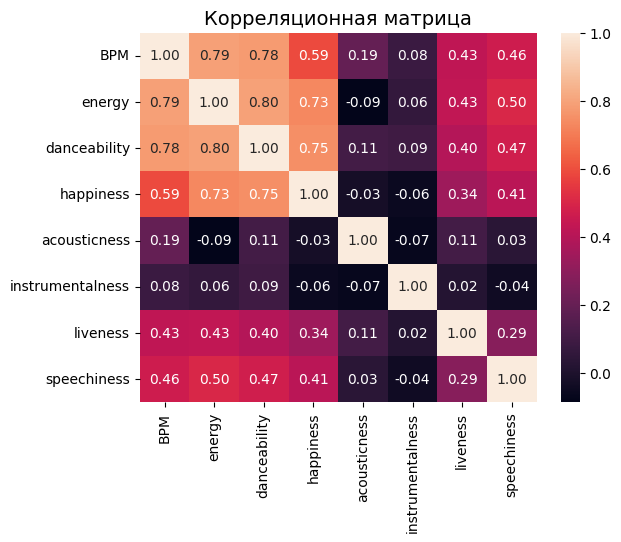

In [ ]:
sns.heatmap(correlation_matrix, annot=True, fmt=".2f")

plt.title('Корреляционная матрица', fontsize=14)

Conclusions (interpretation):

In [ ]:
strong_correlations = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.6:

            strong_correlations.append({
                'feature_1': correlation_matrix.columns[i],
                'feature_2': correlation_matrix.columns[j],
                'correlation': round(corr_value, 2)
            })

if strong_correlations:
    print("Достаточно высокая корреляция у признаков (>0.6):")
    for corr in strong_correlations:
        print(f"{corr['feature_1']} -- {corr['feature_2']} ({corr['correlation']})")

Достаточно высокая корреляция у признаков (>0.6):
BPM -- energy (0.79)
BPM -- danceability (0.78)
energy -- danceability (0.8)
energy -- happiness (0.73)
danceability -- happiness (0.75)


With **plotly**

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

# heatmap корреляционной матрицы
fig = px.imshow(correlation_matrix,
                text_auto='.2f',
                aspect="auto",
                color_continuous_scale='RdBu_r',
                title='Корреляционная матрица')

fig.update_layout(
    title='Корреляционная матрица',
    width=600,
    height=600,
    xaxis_title='Переменные',
    yaxis_title='Переменные'
)

fig.update_xaxes(side="bottom")
fig.update_traces(hovertemplate='<b>X:</b> %{x}<br><b>Y:</b> %{y}<br><b>Корреляция:</b> %{z:.2f}<extra></extra>')

fig.show()

## Task 3

Show on a scatter plot the relationship between `happiness` and `energy` in a composition. Add auxiliary elements to the chart (marking average values, outliers) to simplify the interpretation of the visualization.


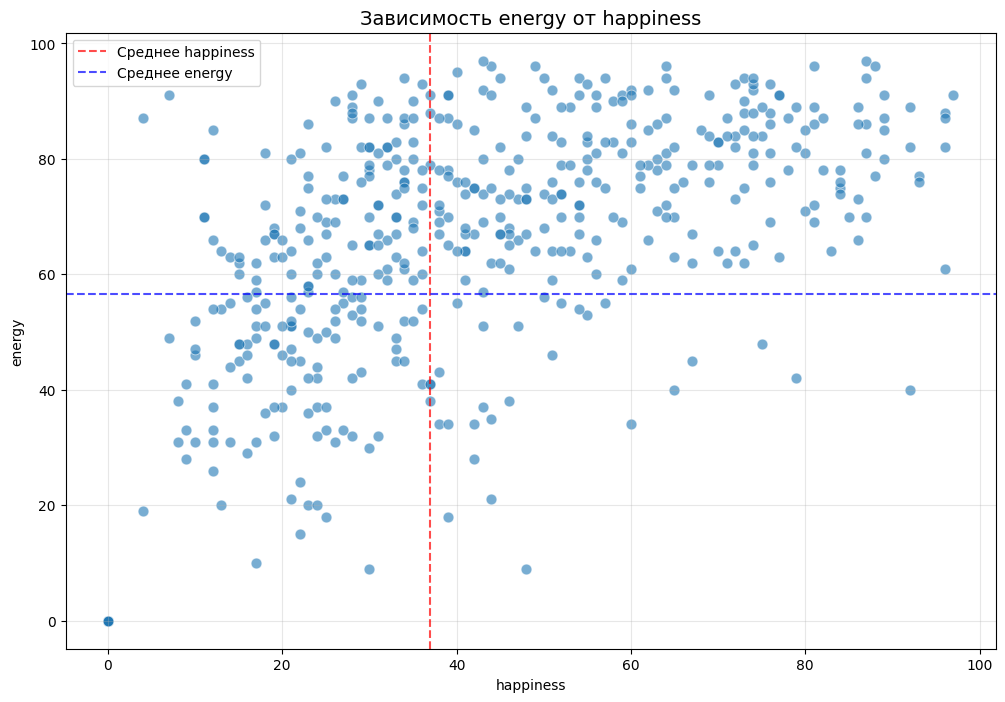

In [ ]:
plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_cleaned, x="happiness", y="energy", alpha=0.6, s=60)

plt.axvline(x=df_cleaned['happiness'].mean(), color='red', linestyle='--', alpha=0.7, label='Среднее happiness')
plt.axhline(y=df_cleaned['energy'].mean(), color='blue', linestyle='--', alpha=0.7, label='Среднее energy')

plt.title('Зависимость energy от happiness', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

There is a direct relationship between the level of happiness and the energy of music

Tracks with higher happiness scores usually also have more energy

That is, positive music is more often energetic, which corresponds to
expectations

With **plotly**

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

fig = px.scatter(df_cleaned,
                 x="happiness",
                 y="energy",
                 opacity=0.6,
                 size_max=60,
                 title='Зависимость energy от happiness')

fig.add_vline(x=df_cleaned['happiness'].mean(),
              line_dash="dash",
              line_color="red",
              opacity=0.7,
              annotation_text="Среднее happiness",
              annotation_position="top right")

fig.add_hline(y=df_cleaned['energy'].mean(),
              line_dash="dash",
              line_color="blue",
              opacity=0.7,
              annotation_text="Среднее energy",
              annotation_position="bottom right")

fig.update_layout(
    width=800,
    height=600,
    showlegend=True,
    xaxis_title="happiness",
    yaxis_title="energy",
    font=dict(size=12),
    plot_bgcolor='white'
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')

fig.show()

## Task 4

Show the distribution of the number of tracks by genre on a horizontal bar graph. Sort the chart in descending order of the number of songs in the genre. Highlight the genre that has the most songs in a contrasting color.

In [ ]:
styles = df_cleaned['style'].unique()
print(styles)

['Pop' 'Rock' 'Ballad' 'Traditional' 'Dance' 'Opera']


With seaborn

/tmp/ipython-input-2523590310.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')


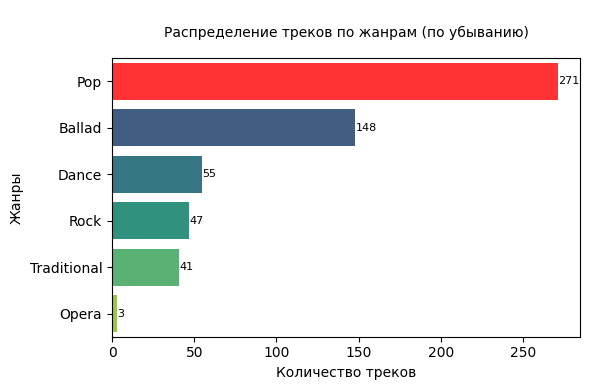

In [ ]:
plt.figure(figsize=(6, 4))

genre_counts = df_cleaned['style'].value_counts()

ax = sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')

ax.patches[0].set_facecolor('red')
ax.patches[0].set_alpha(0.8)

for i, count in enumerate(genre_counts.values):
    plt.text(count + 0.1, i, str(count), va='center', fontsize=8)

plt.title('\nРаспределение треков по жанрам (по убыванию)', fontsize=10, pad=15)
plt.xlabel('Количество треков', fontsize=10)
plt.ylabel('Жанры', fontsize=10)
plt.tight_layout()
plt.show()

With altair

In [ ]:
import altair as alt

genre_counts = df_cleaned['style'].value_counts().reset_index()
genre_counts.columns = ['style', 'count']

chart = alt.Chart(genre_counts).mark_bar(size=35 ).encode(
    x=alt.X('count:Q',
    title='Количество треков'),
    y=alt.Y('style:N',
    title='Жанры',
    sort='-x'),
    color=alt.Color('count:Q', scale=alt.Scale(scheme='viridis'),legend=None))

text = chart.mark_text(
    align='left',
    baseline='middle',
    dx=3,
    fontSize=8
).encode(
    text='count:Q'
)

final_chart = (chart + text).properties(
    width=700,
    height=500,
    title='Распределение треков по жанрам (по убыванию)'
).configure_axis(
    labelFontSize=15,
    titleFontSize=15
).configure_title(
    fontSize=15,
    anchor='start'
)

final_chart

alt.LayerChart(...)

Conclusion: the largest number of tracks in the dataset are represented in the “Pop” genre

## Task 5

Show on a pie chart the countries from which the participants won the most and in which years they won. There should be only one diagram.

In [ ]:
winners_df = df[df['final_place'] == 1]

winner_counts = winners_df['country'].value_counts()
top_winners = winner_counts.head(5)

print("Топ-5 стран по количеству побед на Евровидении")
print(top_winners)

Топ-5 стран по количеству побед на Евровидении
country
Sweden         3
Ukraine        2
Italy          1
Netherlands    1
Israel         1
Name: count, dtype: int64


In [ ]:
years_of_victory = winners_df.groupby('country')['year'].apply(list).to_dict()

print("\nГоды побед для лидирующих стран:")
for country in top_winners.index:
    if country in years_of_victory:

        years_sorted = sorted(years_of_victory[country])
        print(f"- {country}: {', '.join(map(str, years_sorted))}")

winners_df = df[df['final_place'] == 1]

winners_aggregated = winners_df.groupby('country').agg(
    wins=('year', 'count'),
    winning_years=('year', lambda x: sorted(x.astype(str).tolist()))
).sort_values('wins', ascending=False).reset_index()

top_winners = winners_aggregated.head(5)
top_winners['years_label'] = top_winners['winning_years'].apply(lambda years: ', '.join(years))

print(top_winners[['country', 'wins', 'years_label']])


Годы побед для лидирующих стран:
      country  wins       years_label
0      Sweden     3  2012, 2015, 2023
1     Ukraine     2        2016, 2022
2     Austria     1              2014
3     Denmark     1              2013
4  Azerbaijan     1              2011


/tmp/ipython-input-3160934607.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_winners['years_label'] = top_winners['winning_years'].apply(lambda years: ', '.join(years))


In [ ]:
fig = px.pie(top_winners,
             values='wins',
             names='country',
             title='Топ-5 стран-победительниц Евровидения',
             hover_data={'years_label': True, 'wins': True},
             labels={'years_label': 'Годы побед', 'wins': 'Количество побед'})

fig.update_traces(textposition='inside',
                  textinfo='percent+label',
                  hovertemplate='<b>%{label}</b><br>Побед: %{value}<br>Годы: %{customdata[0]}<extra></extra>',
                  textfont_size=14)

fig.show()

## Task 6

Use a vertical grouping bar chart to show the number of male and female participants in each year represented in the dataset.

In [ ]:
gen_un = df_cleaned['gender'].unique()
print(gen_un)

['Female' 'Male' 'Mix']


With seaborn

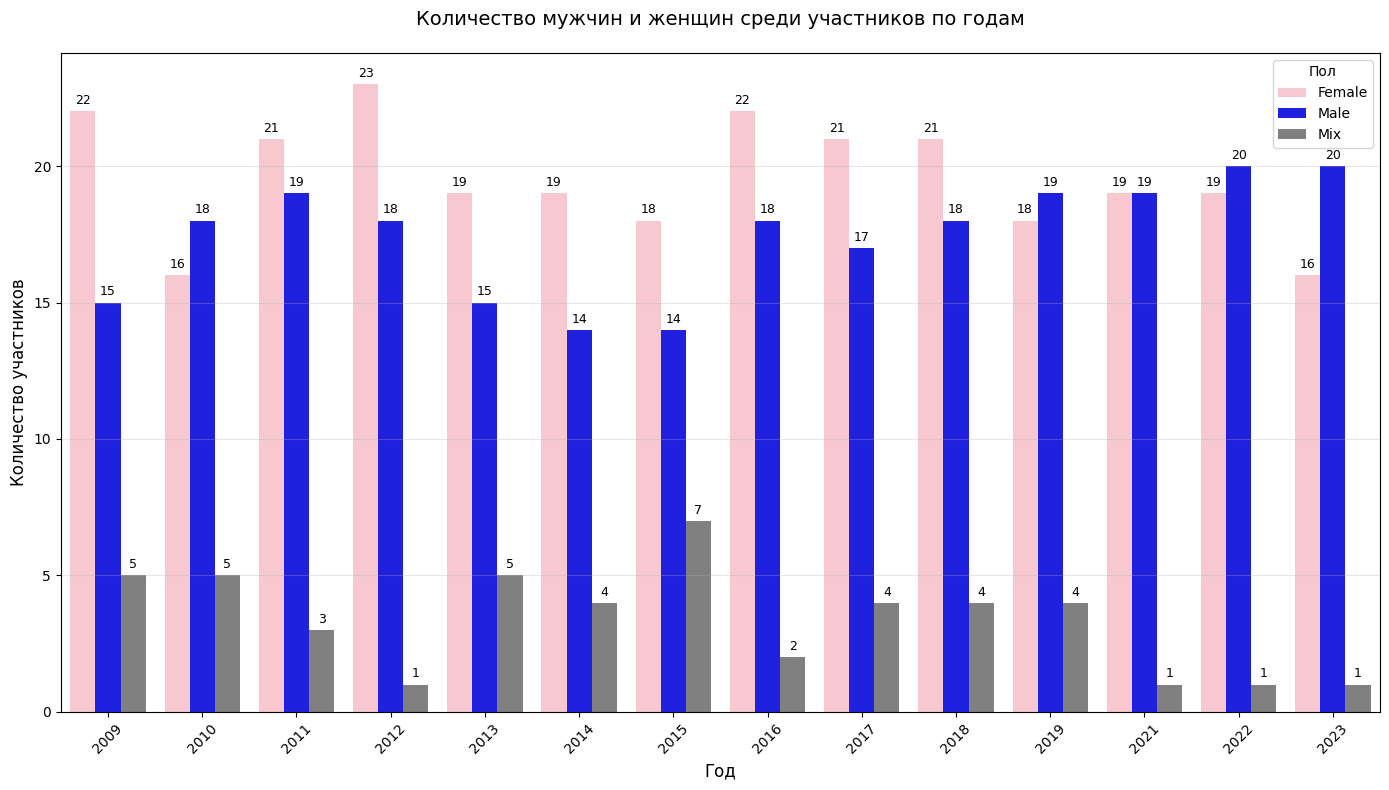

In [ ]:
plt.figure(figsize=(14, 8))

ax = sns.countplot(data=df_cleaned, x='year', hue='gender',
                   palette={'Male': 'blue', 'Female': 'pink', 'Mix': 'gray'})

plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество участников', fontsize=12)
plt.title('Количество мужчин и женщин среди участников по годам', fontsize=14, pad=20)
plt.xticks(rotation=45)
plt.legend(title='Пол')
plt.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

With altair

In [ ]:
import altair as alt

chart_data = df_cleaned.groupby(['year', 'gender']).size().reset_index(name='count')

chart = alt.Chart(chart_data).mark_bar().encode(
    x=alt.X('year:O', title='Год', axis=alt.Axis(labelAngle=-45)),
    y=alt.Y('count:Q', title='Количество участников'),
    color=alt.Color('gender:N',
                   scale=alt.Scale(domain=['Male', 'Female', 'Mix'],
                                  range=['lightblue', 'lightpink', 'gray']),
                   legend=alt.Legend(title='Пол')),
    xOffset=alt.XOffset('gender:N')
)

text = chart.mark_text(
    dy=-5,
    fontSize=9
).encode(
    text=alt.Text('count:Q', format='d'),
    color=alt.value('black')
)

final_chart = (chart + text).properties(
    width=700,
    height=400,
    title='Количество мужчин и женщин среди участников по годам'
).configure_view(
    strokeWidth=0
).configure_axis(
    grid=True,
    gridColor='rgba(0,0,0,0.3)',
    gridOpacity=0.3
)

final_chart

alt.LayerChart(...)

Conclusions:
- in most years there are more women participants than men.
- There is also the opposite, but in such years the gap is small.
- We can also notice a tendency that the distribution of participants by gender is approximately the same; there are no extremely low indicators of one gender relative to the other.

## Task 7

Plot the density distribution of data in the `danceability` column, grouped by category and genre.

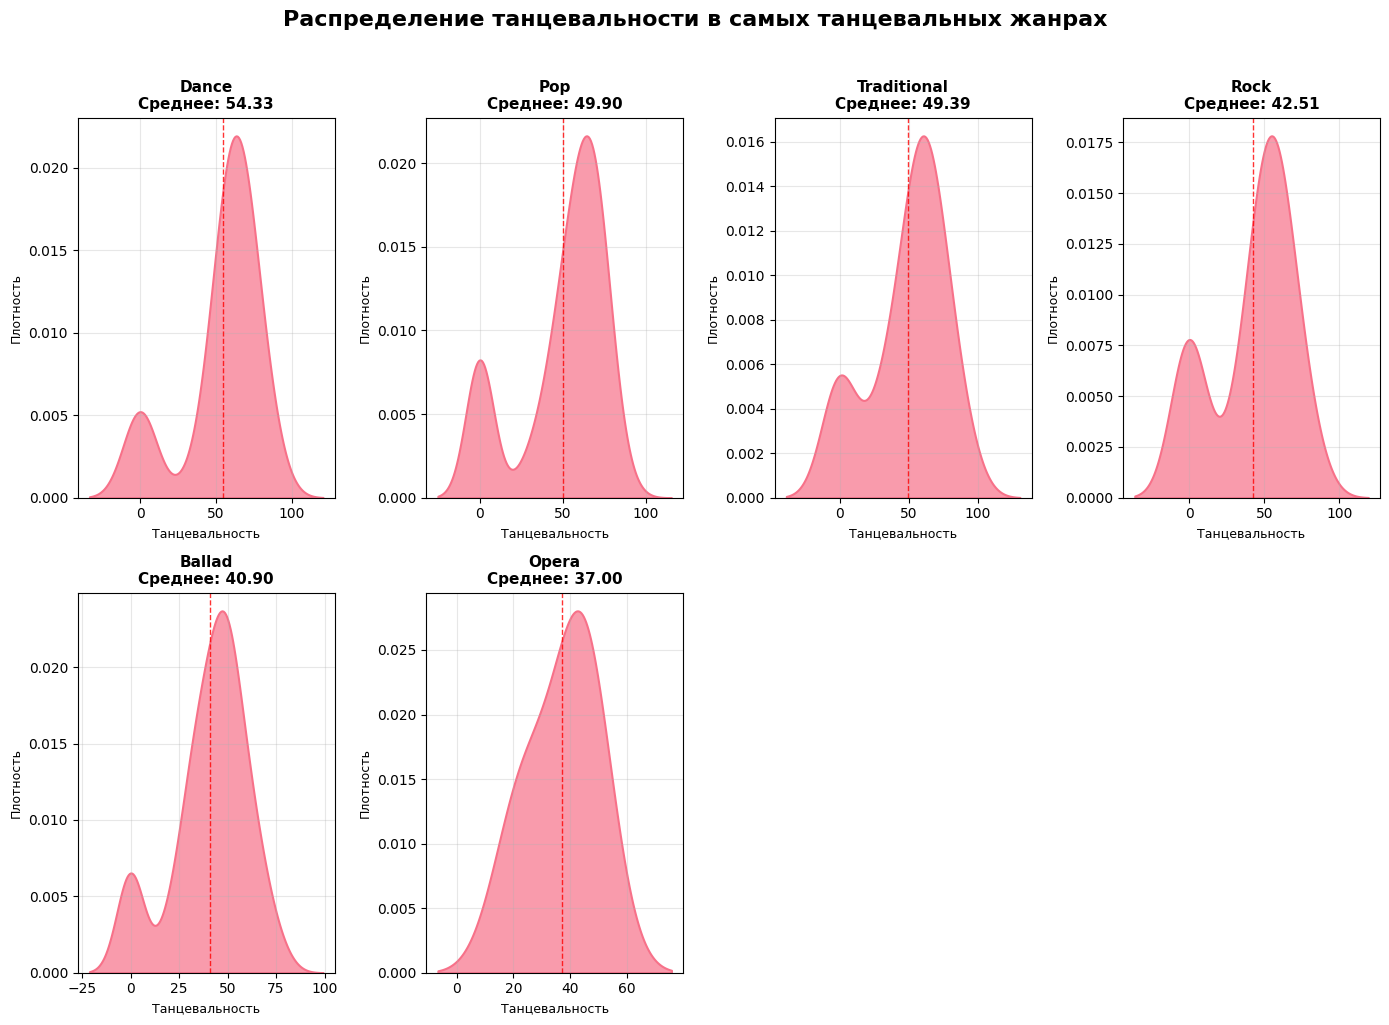

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

top_dance_genres = df_cleaned.groupby('style')['danceability'].mean().nlargest(8).index

plt.style.use('default')
sns.set_palette("husl")

plt.figure(figsize=(14, 10))

for i, genre in enumerate(top_dance_genres, 1):
    plt.subplot(2, 4, i)
    genre_data = df_cleaned[df_cleaned['style'] == genre]['danceability']

    sns.kdeplot(data=genre_data,
                fill=True,
                alpha=0.7,
                linewidth=1.5)

    plt.axvline(genre_data.mean(), color='red', linestyle='--', alpha=0.8, linewidth=1)

    plt.title(f'{genre}\nСреднее: {genre_data.mean():.2f}', fontsize=11, fontweight='bold')
    plt.xlabel('Танцевальность', fontsize=9)
    plt.ylabel('Плотность', fontsize=9)
    plt.grid(True, alpha=0.3)

plt.suptitle('Распределение танцевальности в самых танцевальных жанрах',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

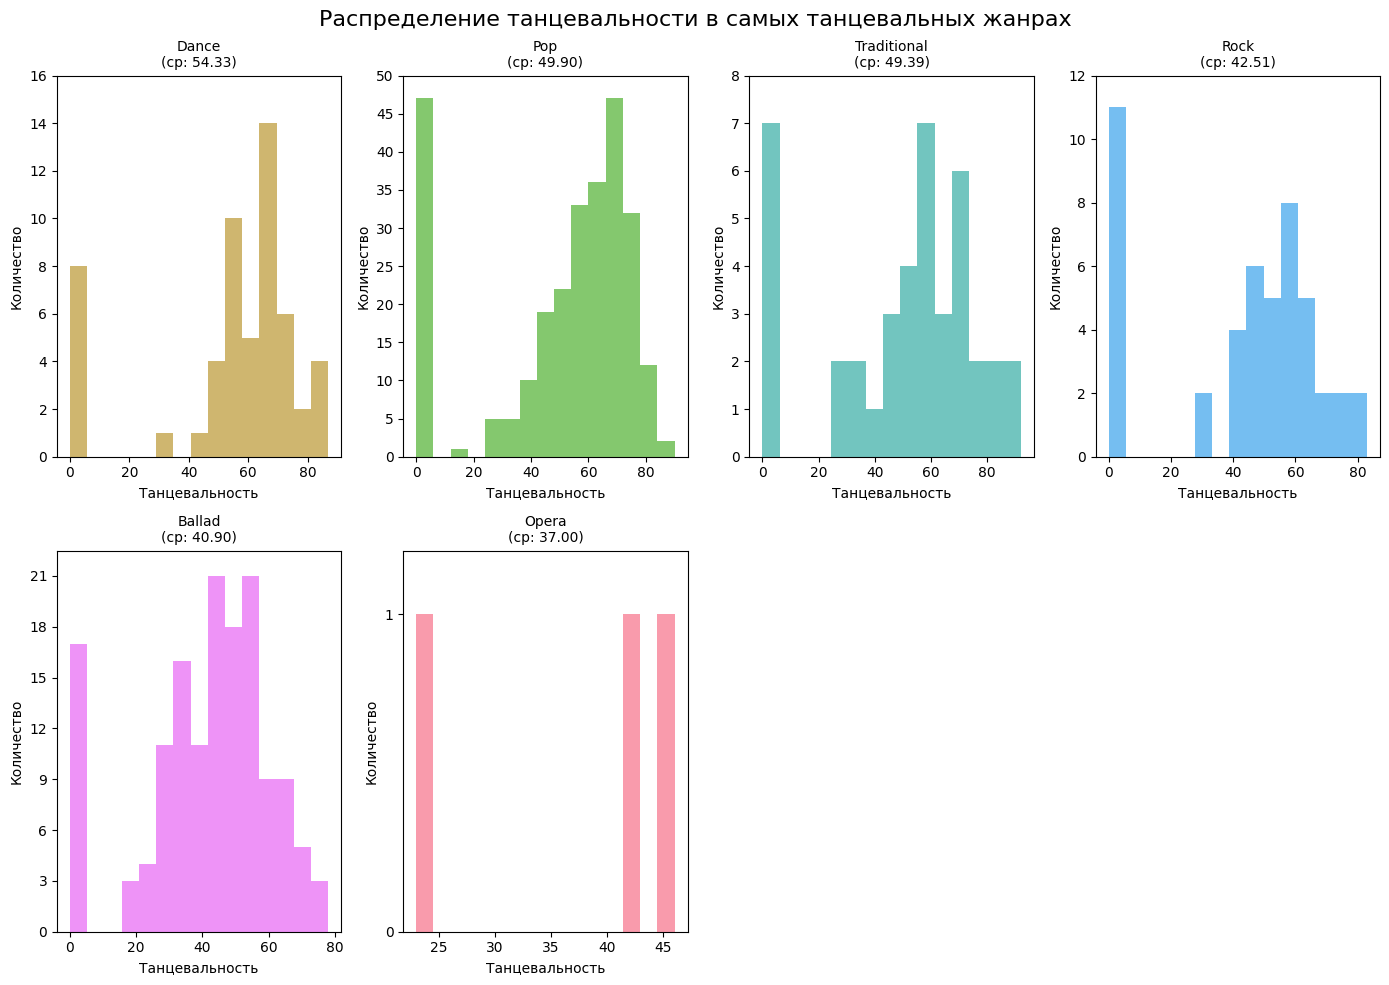

In [ ]:
top_dance_genres = df_cleaned.groupby('style')['danceability'].mean().nlargest(8).index

plt.figure(figsize=(14, 10))

for i, genre in enumerate(top_dance_genres, 1):
    plt.subplot(2, 4, i)
    genre_data = df_cleaned[df_cleaned['style'] == genre]['danceability']
    plt.hist(genre_data, bins=15, alpha=0.7, color=f'C{i}')
    plt.title(f'{genre}\n(ср: {genre_data.mean():.2f})', fontsize=10)
    plt.xlabel('Танцевальность')
    plt.ylabel('Количество')

    plt.yticks(plt.yticks()[0][::1])
    plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.suptitle('Распределение танцевальности в самых танцевальных жанрах', fontsize=16)
plt.tight_layout()
plt.show()

We can notice that the average danceability roughly corresponds to the genre, but for genres where there is not a lot of data, we get a low-quality assessment of danceability, as there are only 3 pieces of data, for example, as is the case with Opera

## Task 8

Show on a box plot the relationship between the position in the final ranking and the country. Which countries' results are similar?

With **seaborn**

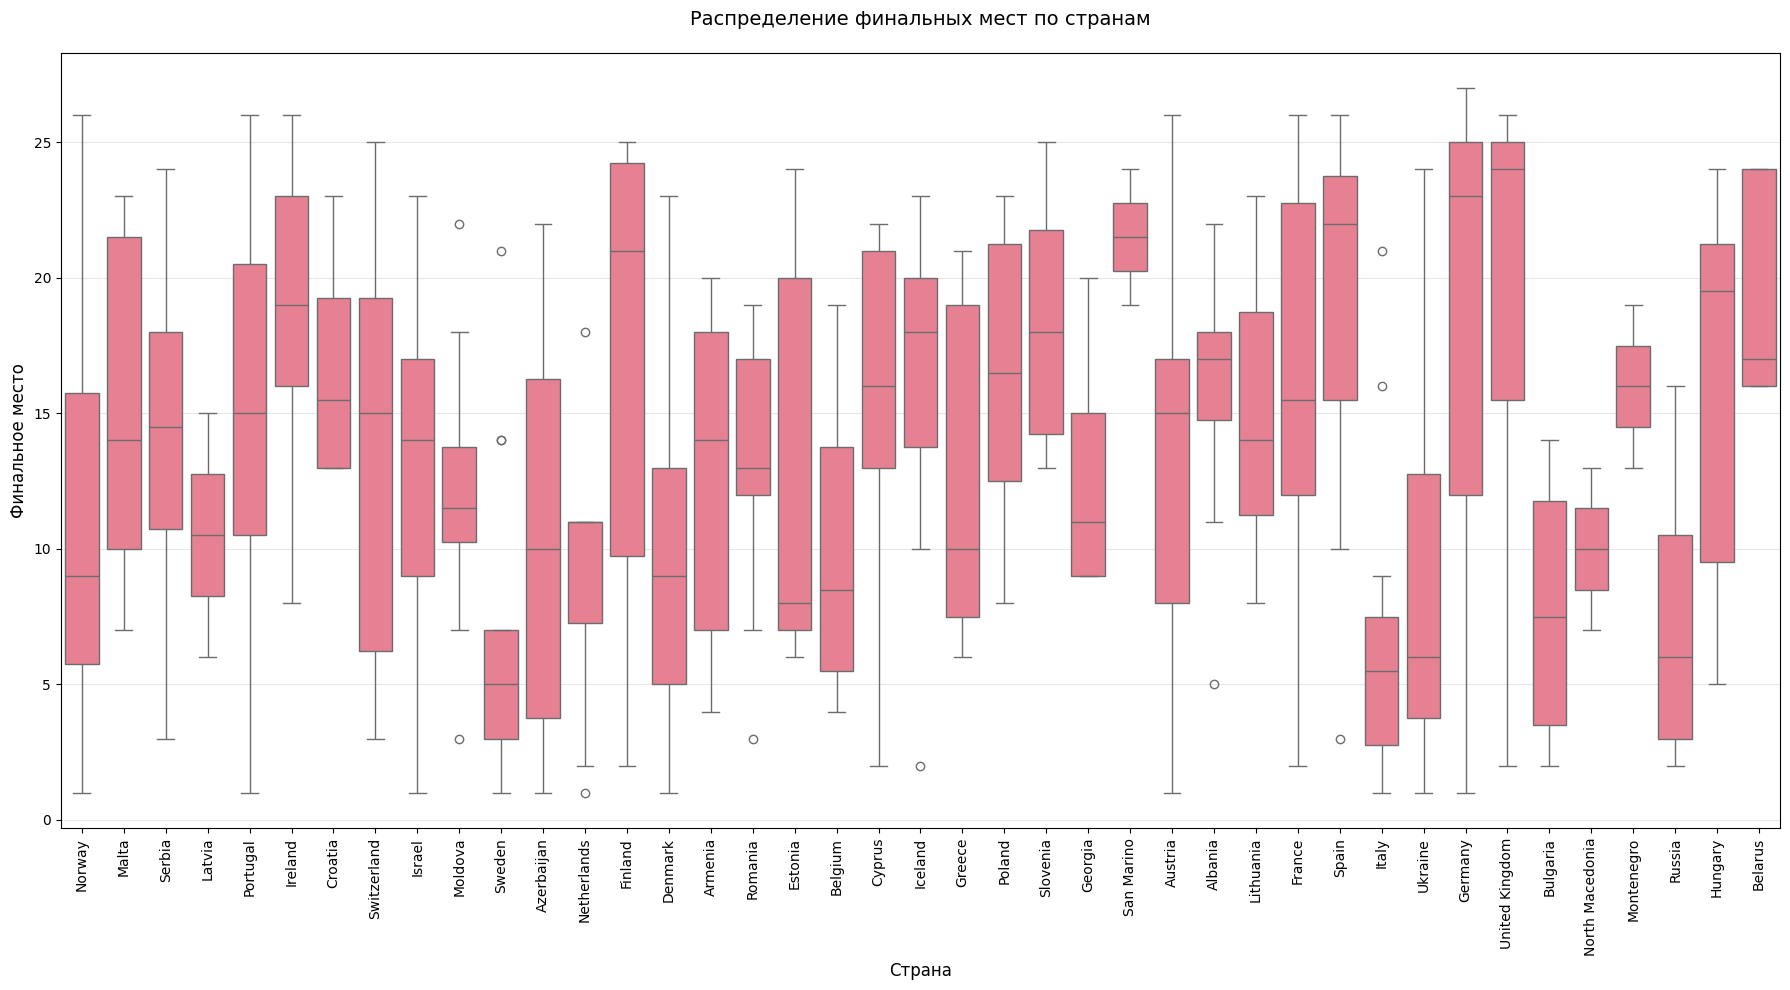

In [ ]:
country_counts = df_cleaned['country'].value_counts()
top_countries = country_counts[country_counts >= 10].index

plt.figure(figsize=(18, 10))
filtered_data = df_cleaned[df_cleaned['country'].isin(top_countries)]
sns.boxplot(data=filtered_data, x="country", y="final_place")
plt.xticks(rotation=90, ha='center', fontsize=10)
plt.yticks(fontsize=10)
plt.title('Распределение финальных мест по странам',
          fontsize=14, pad=20)
plt.xlabel('Страна', fontsize=12)
plt.ylabel('Финальное место', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

- Leading countries - boxes are located low (closer to first place)

Sweden and Italy were previously identified as the most frequent winners, so the diagram accurately reflects the meaning.

- Stable countries - short boxes (low variance)

- Unpredictable countries - long boxes + outliers

- Countries that typically occupy low places - boxes are located high (closer to the last places)

With **altair**

In [ ]:
import altair as alt

country_counts = df_cleaned['country'].value_counts()
top_countries = country_counts[country_counts >= 10].index
filtered_data = df_cleaned[df_cleaned['country'].isin(top_countries)]

chart = alt.Chart(filtered_data).mark_boxplot(extent='min-max').encode(
    x=alt.X('country:N',
            title='Страна',
            axis=alt.Axis(labelAngle=-45, labelFontSize=10),
            sort=alt.EncodingSortField(field='final_place', op='median', order='ascending')),
    y=alt.Y('final_place:Q',
            title='Финальное место',
            scale=alt.Scale(zero=False)),
    color=alt.Color('country:N', legend=None),
    tooltip=['country:N', 'median(final_place):Q', 'min(final_place):Q', 'max(final_place):Q']
).properties(
    width=800,
    height=500,
    title='Распределение финальных мест по странам'
).configure_axis(
    grid=True,
    gridOpacity=0.3
).configure_view(
    strokeWidth=0
)

chart

alt.Chart(...)

- We also see the full picture more clearly:

Sweden, Italy, Ukraine, Russia, and Bulgaria are the leading countries in terms of victories.

- And, for example, Ireland and San Marino have never placed anywhere near the middle.

## Task 9

Show on the map the number of times each country in the dataset has reached the finals.

In [ ]:
import plotly.express as px

country_finals = df_cleaned['country'].value_counts().reset_index()
country_finals.columns = ['country', 'finals_count']

fig = px.choropleth(country_finals,
                    locations='country',
                    locationmode='country names',
                    color='finals_count',
                    color_continuous_scale='Viridis',
                    title='Количество участий в финале по странам',
                    hover_name='country',
                    hover_data={'finals_count': True, 'country': False})

fig.update_layout(
    width=1500,
    height=1500,
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='equirectangular'
    )
)

fig.show()

In [ ]:
pip install geopandas

In [ ]:
import folium
from folium.plugins import StripePattern
import geopandas as gpd
import pandas as pd

# геоданные загрузили
world = gpd.read_file('https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip')

country_finals = df_cleaned['country'].value_counts().reset_index()
country_finals.columns = ['country', 'finals_count']

world_data = world.merge(country_finals, left_on='SOVEREIGNT', right_on='country', how='left')
world_data['finals_count'] = world_data['finals_count'].fillna(0)

# интерактивная карта
m = folium.Map(location=[30, 10], zoom_start=2)

folium.Choropleth(
    geo_data=world_data,
    data=world_data,
    columns=['SOVEREIGNT', 'finals_count'],
    key_on='feature.properties.SOVEREIGNT',
    fill_color='YlGnBu',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Количество участий в финале',
    bins=8,
    reset=True
).add_to(m)

# подсказки при наведении
style_function = lambda x: {'fillColor': '#ffffff',
                          'color':'#000000',
                          'fillOpacity': 0.1,
                          'weight': 0.1}
highlight_function = lambda x: {'fillColor': '#000000',
                              'color':'#000000',
                              'fillOpacity': 0.50,
                              'weight': 0.1}

tooltip = folium.features.GeoJson(
    world_data,
    style_function=style_function,
    control=False,
    highlight_function=highlight_function,
    tooltip=folium.features.GeoJsonTooltip(
        fields=['SOVEREIGNT', 'finals_count'],
        aliases=['Страна:', 'Количество финалов:'],
        style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;")
    )
)
m.add_child(tooltip)
m.keep_in_front(tooltip)

m

Here we see that the European part of our planet was mainly the finalist, moreover, a significant share of the winners came from Scandinavian countries

## Task 10

Show the number of times each country placed in the top 3 winners in a treemap.

In [ ]:
import plotly.express as px

# страны с хотя бы 2 попаданиями в топ-3
top3_counts = df_cleaned[df_cleaned['final_place'] <= 3]['country'].value_counts().reset_index()
top3_counts.columns = ['country', 'top3_count']
top3_counts = top3_counts[top3_counts['top3_count'] >= 2]

names = list(top3_counts['country'])
values = list(top3_counts['top3_count'])
parents = [""] * len(names)

fig = px.treemap(
    names=names,
    parents=parents,
    values=values,
    title='Страны с 2+ попаданиями в топ-3'
)

fig.update_traces(
    root_color="lightgrey",
    textinfo="label+value+percent parent",
    hovertemplate='<b>%{label}</b><br>Топ-3: %{value}<br>Доля: %{percentParent:.1%}<extra></extra>'
)

fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()

Sweden's block occupies 20% of the area, while Israel's block occupies 8%, meaning Sweden was in the top 3 2.5 times more often than Israel among the selected countries with 2+ hits.

And many such comparisons can be made.

- The "2+ hits" filter removes countries with isolated successes to focus on consistently successful countries.

1. seaborn: statistical data visualization [Электронный ресурс]. URL: https://seaborn.pydata.org/ (дата обращения: 01.04.2024).
2. Plotly Open Source Graphing Libraries [Электронный ресурс]. URL: https://plotly.com/graphing-libraries/ (дата обращения: 01.04.2024).
3. Vega-Altair: Declarative Visualization in Python [Электронный ресурс]. URL: https://altair-viz.github.io/index.html (дата обращения: 01.04.2024).